# DQN — Deep Q-Network

In [ ]:
from Environment import SmartAmbulanceEnv
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Video
import copy


## Neural Network

In [2]:
class DQNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1  = nn.Linear(input_size, hidden_size)
        self.fc2  = nn.Linear(hidden_size, hidden_size)
        self.fc3  = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)


## DQN Agent

In [ ]:
class DQNAgent:
    def __init__(self, env, learning_rate=0.001, gamma=0.97,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 memory_size=10000, batch_size=64, target_update=100):

        self.env           = env
        self.n_states      = env.size * env.size
        self.n_actions     = 4
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size    = batch_size
        self.target_update = target_update
        self.update_counter = 0

        self.policy_net = DQNetwork(self.n_states, 128, self.n_actions)
        self.target_net = DQNetwork(self.n_states, 128, self.n_actions)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer  = optim.Adam(self.policy_net.parameters(), lr=learning_rate)
        self.memory     = deque(maxlen=memory_size)

    def state_to_tensor(self, state):
        one_hot = np.zeros(self.n_states, dtype=np.float32)
        one_hot[state] = 1.0
        return torch.FloatTensor(one_hot).unsqueeze(0)

    def choose_action(self, state, training=True):
        if training and np.random.random() < self.epsilon:
            return np.random.randint(0, self.n_actions)
        with torch.no_grad():
            return int(torch.argmax(self.policy_net(self.state_to_tensor(state))).item())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return 0.0
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states_t      = torch.FloatTensor(np.eye(self.n_states, dtype=np.float32)[list(states)])
        next_states_t = torch.FloatTensor(np.eye(self.n_states, dtype=np.float32)[list(next_states)])
        actions_t  = torch.LongTensor(actions)
        rewards_t  = torch.FloatTensor(rewards)
        dones_t    = torch.FloatTensor(dones)

        current_q = self.policy_net(states_t).gather(1, actions_t.unsqueeze(1))
        with torch.no_grad():
            next_q   = self.target_net(next_states_t).max(1)[0]
            target_q = rewards_t + (1 - dones_t) * self.gamma * next_q

        loss = nn.MSELoss()(current_q.squeeze(), target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.update_counter += 1
        if self.update_counter % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())
        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def train(self, episodes=3000, max_steps=500, verbose=True):
        episode_rewards, episode_losses = [], []
        for episode in range(episodes):
            state, _ = self.env.reset()
            done, total_reward, episode_loss, steps = False, 0, 0.0, 0

            while not done and steps < max_steps:
                steps += 1
                action = self.choose_action(state, training=True)
                next_state, reward, done, _, _ = self.env.step(action)
                self.remember(state, action, reward, next_state, done)
                loss = self.replay()
                if loss > 0: episode_loss += loss
                state = next_state
                total_reward += reward

            episode_rewards.append(total_reward)
            episode_losses.append(episode_loss / max(steps, 1))
            self.decay_epsilon()

            if verbose and episode % 100 == 0:
                avg = np.mean(episode_rewards[-100:]) if len(episode_rewards)>=100 else np.mean(episode_rewards)
                print(f"Episode {episode:4d} | Avg(100): {avg:7.2f} | Epsilon: {self.epsilon:.3f}")

        return episode_rewards, episode_losses

    def evaluate(self, episodes=50, max_steps=500):
        rewards, success_count = [], 0
        for _ in range(episodes):
            state, _ = self.env.reset()
            done, total_reward, steps = False, 0, 0
            while not done and steps < max_steps:    # ✅ max_steps guard
                steps += 1
                action = self.choose_action(state, training=False)
                state, reward, done, _, _ = self.env.step(action)
                total_reward += reward
            rewards.append(total_reward)
            if done and reward == 100:
                success_count += 1
        avg          = np.mean(rewards)
        success_rate = success_count / episodes * 100
        print(f"\nDQN Evaluation:")
        print(f"  Average Reward : {avg:.2f} ± {np.std(rewards):.2f}")
        print(f"  Success Rate   : {success_rate:.1f}%")
        return avg, success_rate


## Training

In [ ]:
env = SmartAmbulanceEnv(size=20, seed=69)

print("Training DQN Agent...")
dqn_agent = DQNAgent(env, learning_rate=0.001, gamma=0.97,
                     epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                     memory_size=10000, batch_size=64, target_update=100)

dqn_rewards, dqn_losses = dqn_agent.train(episodes=3000)


Training DQN Agent...
Episode    0 | Avg(100): -774.00 | Epsilon: 0.995
Episode  100 | Avg(100): -489.97 | Epsilon: 0.603
Episode  200 | Avg(100):  -10.40 | Epsilon: 0.365
Episode  300 | Avg(100):   23.77 | Epsilon: 0.221
Episode  400 | Avg(100):   35.84 | Epsilon: 0.134
Episode  500 | Avg(100):   38.66 | Epsilon: 0.081
Episode  600 | Avg(100):   45.37 | Epsilon: 0.049
Episode  700 | Avg(100):   43.64 | Epsilon: 0.030
Episode  800 | Avg(100):   46.00 | Epsilon: 0.018
Episode  900 | Avg(100):   49.55 | Epsilon: 0.011


## Save Model

In [5]:
torch.save(dqn_agent.policy_net.state_dict(), 'dqn_ambulance.pth')
print("Model saved as dqn_ambulance.pth")


Model saved as dqn_ambulance.pth


## Evaluation

In [6]:
dqn_score, dqn_success = dqn_agent.evaluate()



DQN Evaluation:
  Average Reward : 52.70 ± 12.35
  Success Rate   : 100.0%


## Learning Curve & Loss

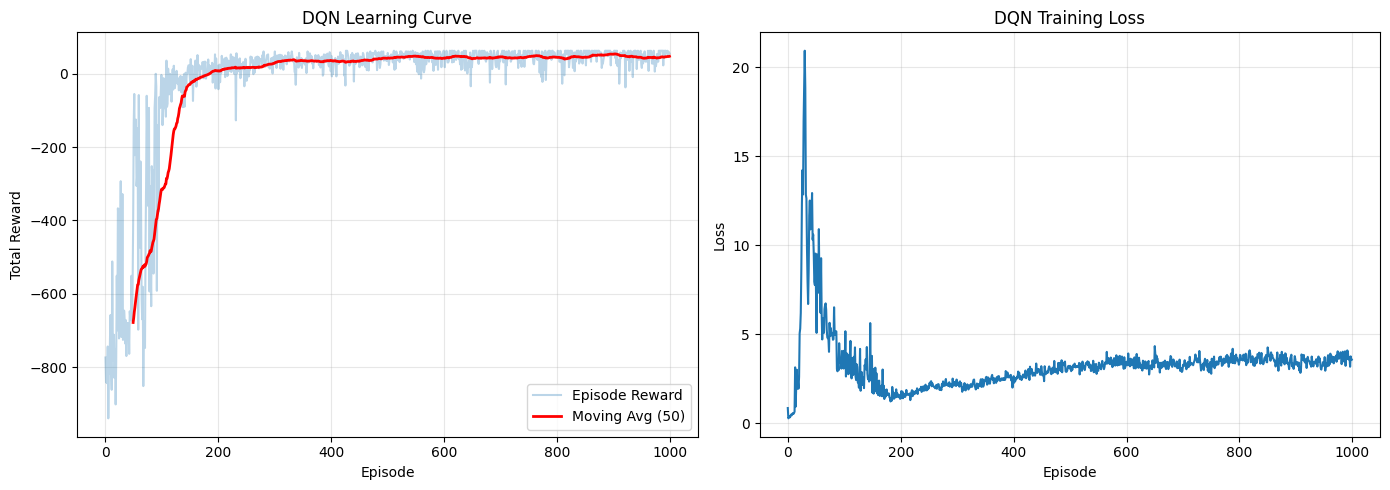

In [7]:
window     = 50
moving_avg = np.convolve(dqn_rewards, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(dqn_rewards, alpha=0.3, label='Episode Reward')
axes[0].plot(range(window-1, len(dqn_rewards)), moving_avg,
             'r-', linewidth=2, label=f'Moving Avg ({window})')
axes[0].set(xlabel='Episode', ylabel='Total Reward', title='DQN Learning Curve')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(dqn_losses)
axes[1].set(xlabel='Episode', ylabel='Loss', title='DQN Training Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_learning_curve.png', dpi=120)
plt.show()


## Trajectory Animation

Total steps: 38
Saved: dqn_navigation.mp4


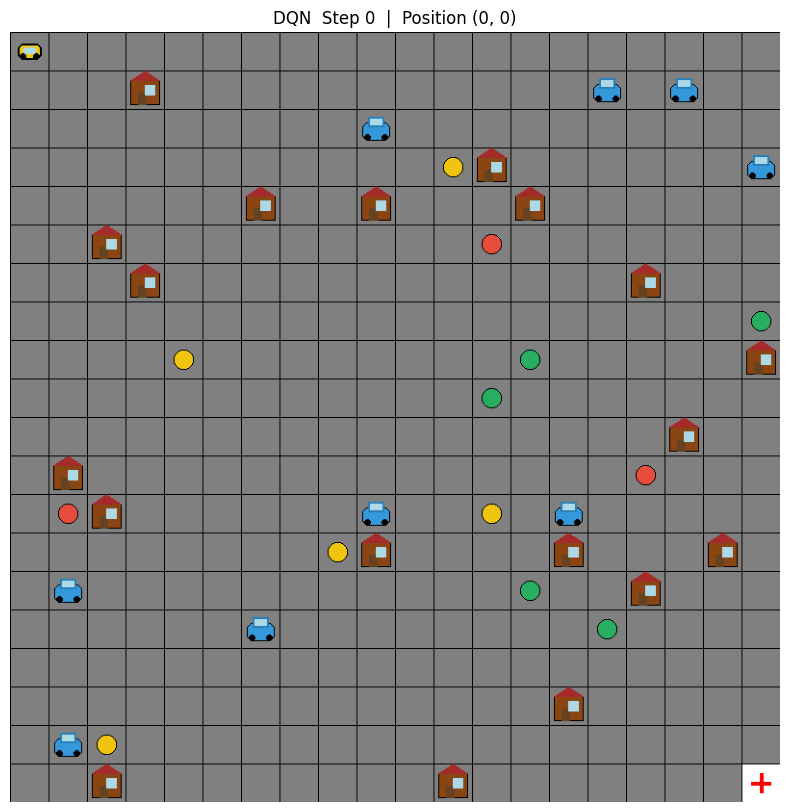

In [8]:
state, _ = env.reset()
done, steps = False, 0
states_history = [state]
lights_history = [copy.deepcopy(env.traffic_lights)]
grid_history   = [env._grid.copy()]

while not done and steps < 200:
    steps += 1
    action = dqn_agent.choose_action(state, training=False)
    state, reward, done, _, _ = env.step(action)
    states_history.append(state)
    lights_history.append(copy.deepcopy(env.traffic_lights))
    grid_history.append(env._grid.copy())

print(f"Total steps: {len(states_history)-1}")

fig, ax = plt.subplots(figsize=(10, 10))
def update(frame):
    ax.clear()
    env._grid = grid_history[frame]
    ax.imshow(env.render_frame(states_history[frame], lights_history[frame]))
    r, c = divmod(states_history[frame], env.cols)
    ax.set_title(f"DQN  Step {frame}  |  Position ({r}, {c})")
    ax.axis('off')

anim = FuncAnimation(fig, update, frames=len(states_history), interval=100, repeat=False)
anim.save('dqn_navigation.mp4', writer='ffmpeg', fps=10)
print("Saved: dqn_navigation.mp4")
Video('dqn_navigation.mp4', embed=True)
